Columns in data: ['time', 'x1', 'y1', 'z1', 'x2', 'y2', 'z2']


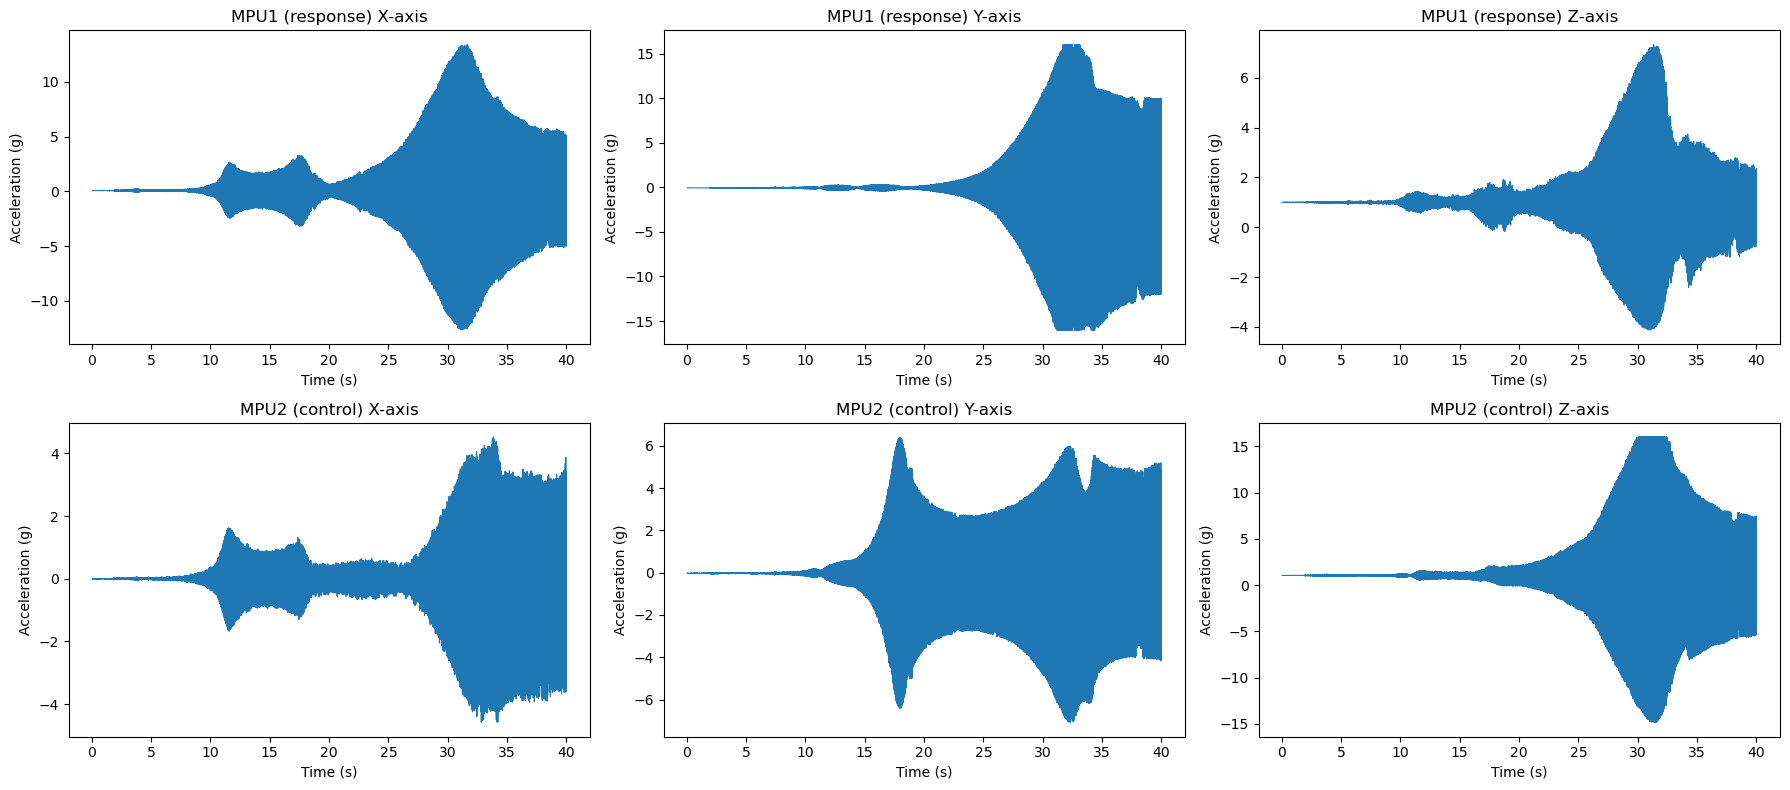

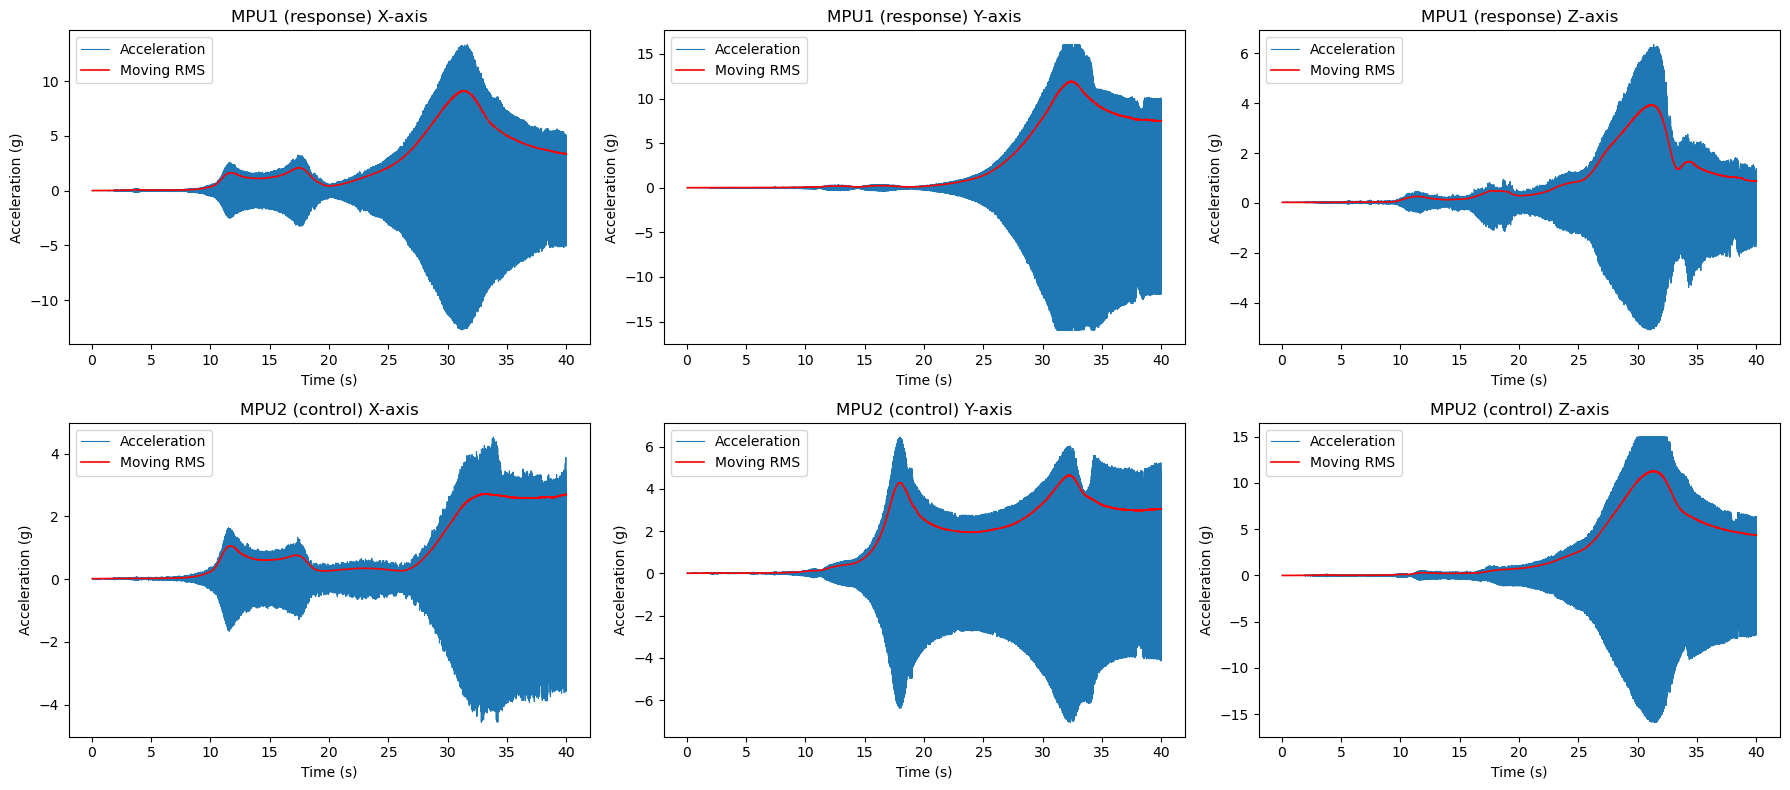

Axis x1: Time-domain RMS = 3.6031 g
Axis y1: Time-domain RMS = 4.8977 g
Axis z1: Time-domain RMS = 1.6881 g
Axis x2: Time-domain RMS = 1.3544 g
Axis y2: Time-domain RMS = 2.3517 g
Axis z2: Time-domain RMS = 4.5372 g


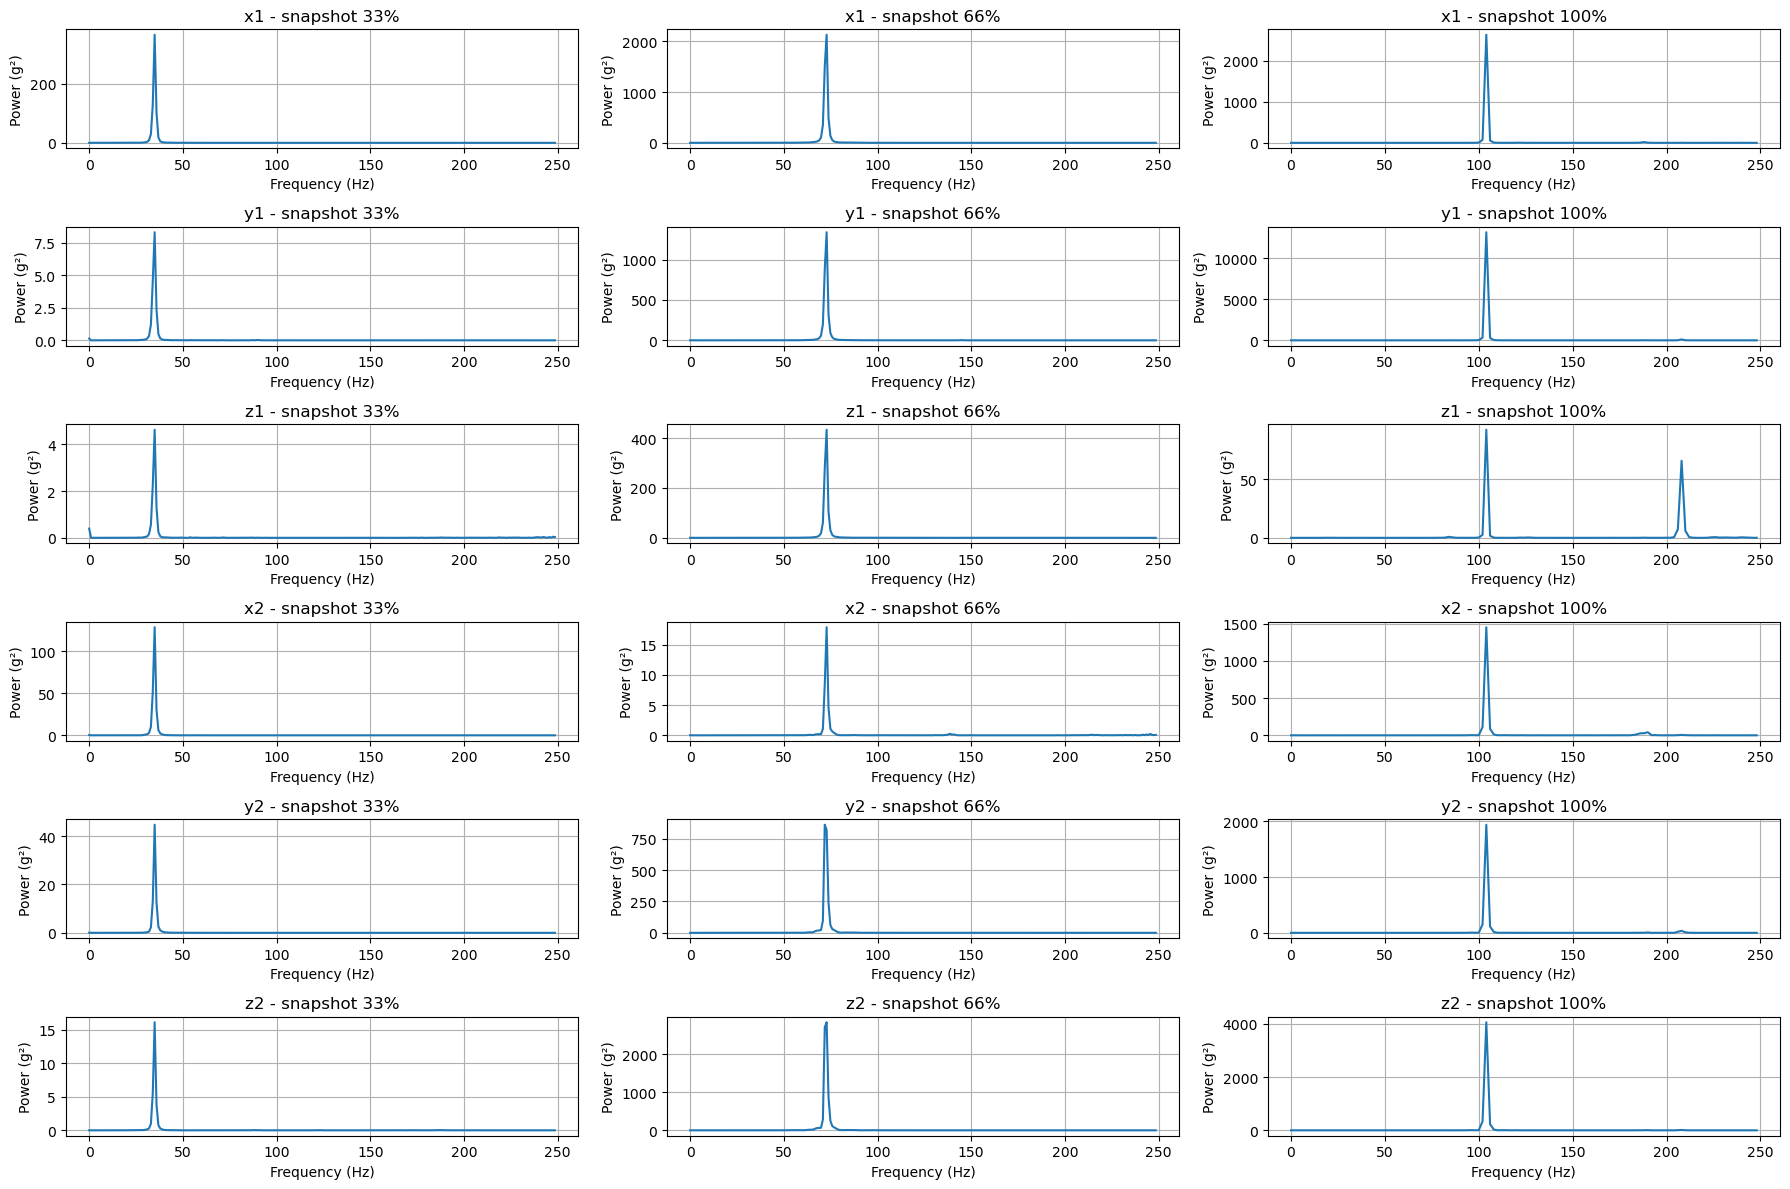

RMS of max FFT: {'x1': np.float64(29.384754489963694), 'y1': np.float64(32.66815997443263), 'z1': np.float64(12.766029341304264), 'x2': np.float64(8.151386458645458), 'y2': np.float64(13.865265254820677), 'z2': np.float64(39.78058683548149)}


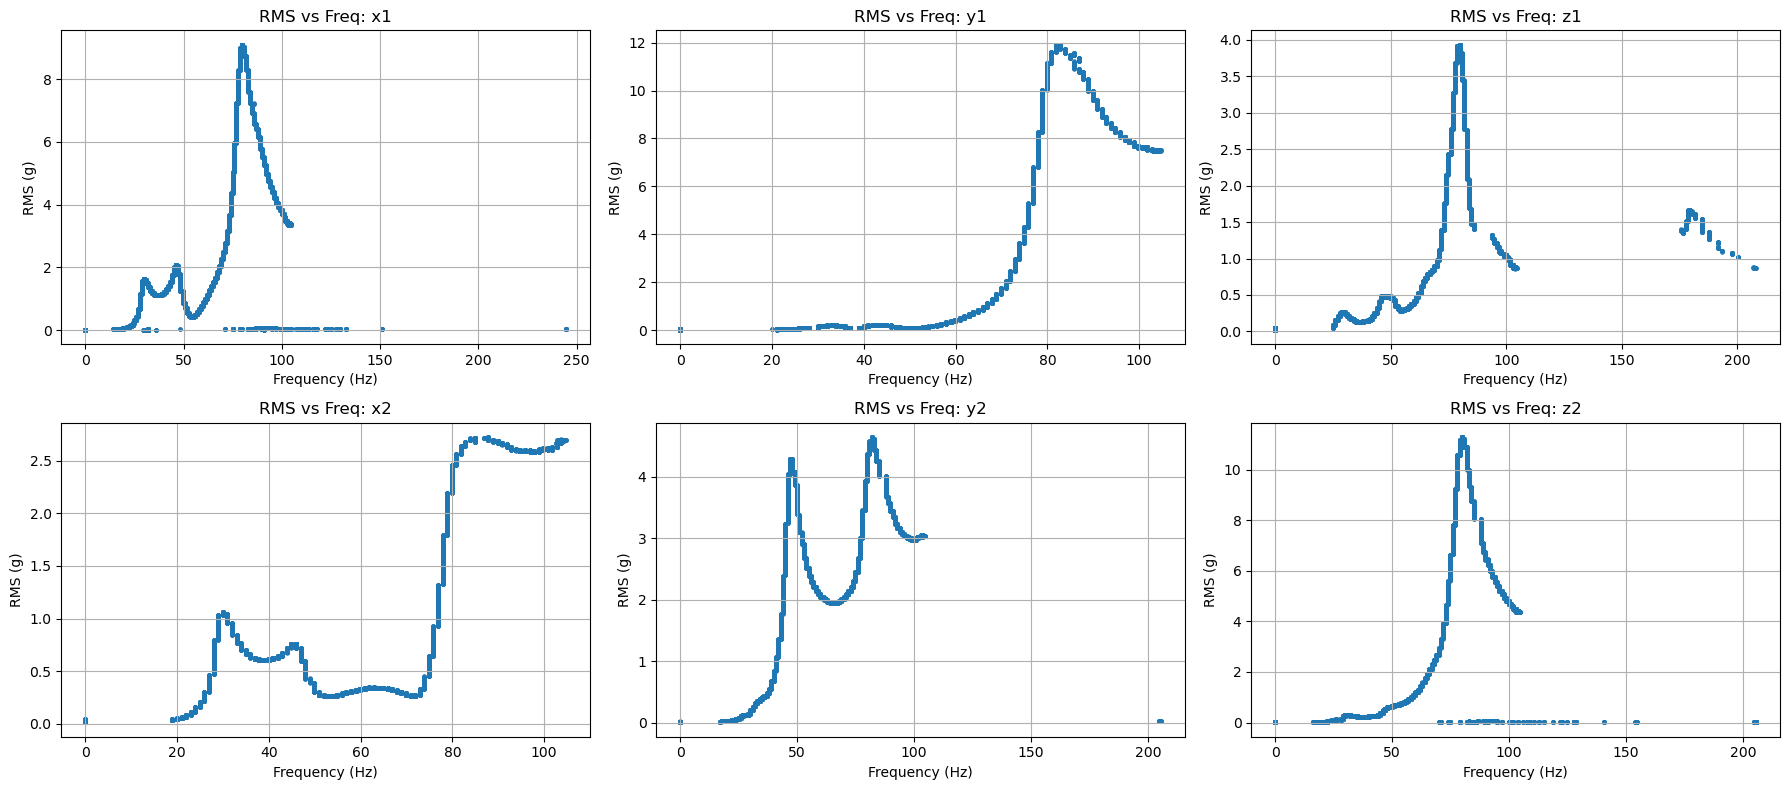

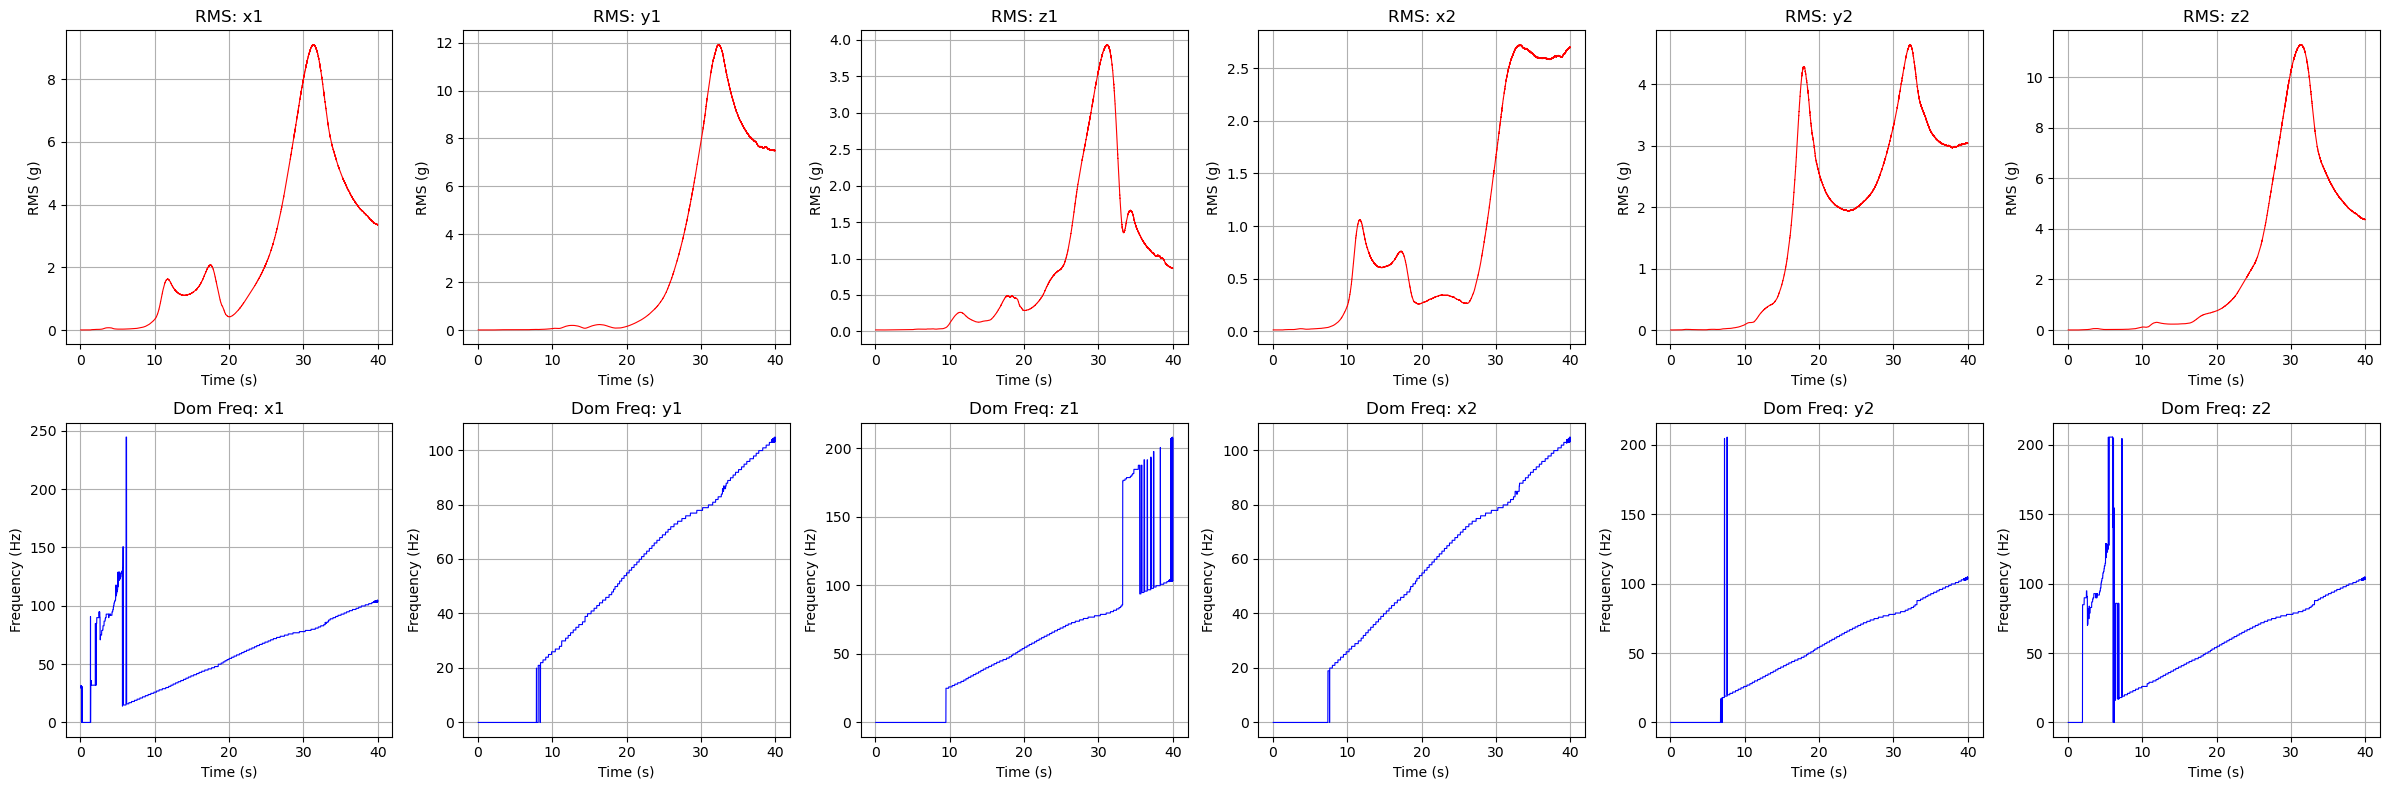

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Load data
# -----------------------------
data = pd.read_csv('withola13.csv')
data.columns = data.columns.str.replace('"', '').str.strip()
print("Columns in data:", data.columns.tolist())

# -----------------------------
# Sampling parameters
# -----------------------------
fs = 500.0  # Hz
dt = 1.0 / fs
time = data['time'].values / 1000.0  # convert ms to seconds
N = len(data)

axes = ['x1','y1','z1','x2','y2','z2']
titles = ["MPU1 (response) X-axis", "MPU1 (response) Y-axis", "MPU1 (response) Z-axis",
          "MPU2 (control) X-axis", "MPU2 (control) Y-axis", "MPU2 (control) Z-axis"]

# -----------------------------
# 1. Time-series plots
# -----------------------------
fig, axs = plt.subplots(2, 3, figsize=(18, 8))
axs = axs.flatten()
for i, col in enumerate(axes):
    axs[i].plot(time, data[col].values, linewidth=0.8)
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Time (s)")
    axs[i].set_ylabel("Acceleration (g)")
plt.tight_layout()
plt.show()

# -----------------------------
# 2. Time-series plots with moving RMS
# -----------------------------
window_sec = 1.0
window_size = int(window_sec * fs)
half_window = window_size // 2

fig, axs = plt.subplots(2, 3, figsize=(18, 8))
axs = axs.flatten()
for i, col in enumerate(axes):
    y = data[col].values - np.mean(data[col].values)
    rms_moving = np.zeros(N)
    for j in range(N):
        start = max(0, j - half_window)
        end = min(N, j + half_window + 1)
        rms_moving[j] = np.sqrt(np.mean(y[start:end]**2))
    axs[i].plot(time, y, linewidth=0.8, label='Acceleration')
    axs[i].plot(time, rms_moving, color='red', linewidth=1.2, label='Moving RMS')
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Time (s)")
    axs[i].set_ylabel("Acceleration (g)")
    axs[i].legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 3. RMS of each axis (entire signal)
# -----------------------------
rms_time_domain = {col: np.sqrt(np.mean(data[col].values**2)) for col in axes}
for col, val in rms_time_domain.items():
    print(f"Axis {col}: Time-domain RMS = {val:.4f} g")

# -----------------------------
# 4. FFT snapshots (33%,66%,100%)
# -----------------------------
snapshot_percents = [0.33,0.66,1]
fig, axs = plt.subplots(len(axes), len(snapshot_percents), figsize=(18,12))
axs = axs.reshape(len(axes), len(snapshot_percents))
for i, col in enumerate(axes):
    y = data[col].values - np.mean(data[col].values)
    for j, perc in enumerate(snapshot_percents):
        center = int(N * perc)
        start = max(0, center - half_window)
        end = min(N, center + half_window + 1)
        window = y[start:end]
        W = np.fft.fft(window)
        freqs = np.fft.fftfreq(len(window), dt)[:len(window)//2]
        power = (2.0 / len(window)) * np.abs(W[:len(window)//2])**2
        axs[i,j].plot(freqs, power)
        axs[i,j].set_title(f"{col} - snapshot {int(perc*100)}%")
        axs[i,j].set_xlabel("Frequency (Hz)")
        axs[i,j].set_ylabel("Power (g²)")
        axs[i,j].grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 5. RMS of maximum FFT
# -----------------------------
rms_max_fft = {}
for col in axes:
    y = data[col].values - np.mean(data[col].values)
    W = np.fft.fft(y)
    power = (2.0 / N) * np.abs(W)**2
    rms_max_fft[col] = np.sqrt(np.max(power))
print("RMS of max FFT:", rms_max_fft)

# -----------------------------
# 6. RMS vs dominant frequency (scatter plots)
# -----------------------------
accel_axes = [('x1','x2'),('y1','y2'),('z1','z2')]
fig, axs = plt.subplots(2,3,figsize=(18,8))
axs = axs.flatten()
for idx, (a1,a2) in enumerate(accel_axes):
    for sensor, ax in zip([a1,a2],[axs[idx],axs[idx+3]]):
        y = data[sensor].values - np.mean(data[sensor].values)
        rms_list = []
        dom_freq_list = []
        for i in range(N):
            start = max(0, i - half_window)
            end = min(N, i + half_window + 1)
            window = y[start:end]
            rms = np.sqrt(np.mean(window**2))
            W = np.fft.fft(window)
            freqs_win = np.fft.fftfreq(len(window), dt)[:len(window)//2]
            power = (2.0/len(window)) * np.abs(W[:len(window)//2])**2
            dom_freq = freqs_win[np.argmax(power)]
            rms_list.append(rms)
            dom_freq_list.append(dom_freq)
        ax.scatter(dom_freq_list, rms_list, s=5)
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('RMS (g)')
        ax.set_title(f'RMS vs Freq: {sensor}')
        ax.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 7. RMS and dominant frequency over time (12 subplots)
# -----------------------------
results = {}
for col in axes:
    y = data[col].values - np.mean(data[col].values)
    rms_list = np.zeros(N)
    dom_freq_list = np.zeros(N)
    for i in range(N):
        start = max(0,i-half_window)
        end = min(N,i+half_window+1)
        window = y[start:end]
        rms_list[i] = np.sqrt(np.mean(window**2))
        W = np.fft.fft(window)
        freqs_win = np.fft.fftfreq(len(window), dt)[:len(window)//2]
        power = (2.0/len(window)) * np.abs(W[:len(window)//2])**2
        dom_freq_list[i] = freqs_win[np.argmax(power)]
    results[col] = {"rms": rms_list, "dom_freq": dom_freq_list}

fig, axs = plt.subplots(2,6,figsize=(24,8))
axs = axs.flatten()
for i,col in enumerate(axes):
    axs[i].plot(time, results[col]["rms"], color='red', linewidth=0.8)
    axs[i].set_title(f"RMS: {col}")
    axs[i].set_xlabel("Time (s)")
    axs[i].set_ylabel("RMS (g)")
    axs[i].grid(True)
for i,col in enumerate(axes):
    axs[i+6].plot(time, results[col]["dom_freq"], color='blue', linewidth=0.8)
    axs[i+6].set_title(f"Dom Freq: {col}")
    axs[i+6].set_xlabel("Time (s)")
    axs[i+6].set_ylabel("Frequency (Hz)")
    axs[i+6].grid(True)
plt.tight_layout()
plt.show()
